<div style="text-align:center; padding: 2em 0 1em 0;">
<h1 style="font-size:2.6em; margin-bottom:0.2em;">Quantum Computing with Code</h1>
<h3 style="font-weight:normal; color:#555; margin-top:0;">A hands-on course: theory, Qiskit code, visuals, simulation</h3>
<p style="color:#777; margin-top:1.5em;">Nine notebooks that take you from "what is a qubit?" to running quantum algorithms on a noisy simulated quantum computer.</p>
</div>

## Who this is for

You can write a little Python and remember what a vector and a matrix are. That is all.
No physics background is assumed. Every idea is introduced three times: as an **analogy**, as **maths**,
and as **code you run and modify**.

By the end you will be able to:

* explain superposition, entanglement, measurement and interference using state vectors, not slogans;
* build and simulate quantum circuits in **Qiskit**, and read their results correctly;
* implement quantum teleportation, the Deutsch-Jozsa algorithm and Grover's search from scratch;
* understand *why* real quantum computers are noisy, and see the simplest error-correcting code work.

## Course map

| # | Notebook | What you learn | Qiskit tools introduced |
|---|----------|----------------|-------------------------|
| 0 | [Start Here](00_Start_Here.ipynb) | Setup check, the four Qiskit objects, conventions, glossary | `QuantumCircuit`, `Statevector`, `Operator`, `AerSimulator` |
| 1 | [The Qubit & Superposition](01_The_Qubit_and_Superposition.ipynb) | Bits vs qubits, amplitudes, Dirac notation, Bloch sphere, first measurement | `Statevector`, `plot_bloch_multivector`, `plot_histogram` |
| 2 | [Quantum Logic Gates](02_Quantum_Logic_Gates.ipynb) | Gates as rotations, Pauli X/Y/Z, Hadamard, rotation & phase gates, circuits as programs | `Operator`, `array_to_latex`, `ry`, `interact` |
| 3 | [Multiple Qubits & Entanglement](03_Multiple_Qubits_and_Entanglement.ipynb) | Tensor products, bit ordering, CNOT, Bell & GHZ states, an entanglement test | `from_label`, `partial_trace`, `cx`, `purity` |
| 4 | [Measurement & Interference](04_Measurement_and_Interference.ipynb) | Born rule, shot noise, measurement bases, phase, a quantum interferometer | `probabilities_dict`, `sample_counts`, `rz` |
| 5 | [Quantum Teleportation](05_Quantum_Teleportation.ipynb) | No-cloning, the protocol, deferred measurement vs real feed-forward, fidelity | `if_test`, `ClassicalRegister`, `state_fidelity`, `marginal_counts` |
| 6 | [Deutsch-Jozsa, the First Quantum Speed-up](06_Deutsch_Jozsa_Algorithm.ipynb) | Oracles, phase kickback, one query beats many, Bernstein-Vazirani | `compose`, `to_gate`, custom oracles |
| 7 | [Grover's Search](07_Grovers_Search.ipynb) | Amplitude amplification, oracle + diffuser, optimal iterations, scaling | `mcx`, `to_gate`, amplitude plots |
| 8 | [Noise, Real Hardware & Error Correction](08_Noise_and_Real_Hardware.ipynb) | Noise models, depth vs error, transpiling to hardware, repetition code | `NoiseModel`, `depolarizing_error`, `ReadoutError`, `GenericBackendV2`, `transpile` |

**Suggested path:** modules 1 to 5 build on each other and form the core. Modules 6 and 7 are the first real algorithms.
Module 8 is the reality check: what changes when the computer is noisy.

## How to use each module

Every module follows the same rhythm:

1. **Learning objectives** at the top tell you what you should be able to do afterwards.
2. **Theory** is broken into short sections, each followed immediately by code that demonstrates it.
3. **"What to notice"** callouts point at the detail in the plot or output that matters.
4. **Try it yourself** exercises at the end. Solutions are hidden behind a *Solutions* toggle. Attempt first!
5. **Key takeaways** summarise the module in a few lines.

Run every cell (`Shift+Enter`), then *change something* and run it again. The simulator is free, so experiment.
Cells with sliders are interactive: drag the slider and the plot updates.

## Environment check

Run this cell first. It confirms the `quantum_computing` kernel has every library the course needs.

In [1]:
import sys
import qiskit, qiskit_aer, numpy, matplotlib, ipywidgets, sympy

print(f"Python      {sys.version.split()[0]}")
print(f"Interpreter {sys.executable}")
print()
for name, mod in [("qiskit", qiskit), ("qiskit-aer", qiskit_aer), ("numpy", numpy),
                  ("matplotlib", matplotlib), ("ipywidgets", ipywidgets), ("sympy", sympy)]:
    print(f"{name:<12}{mod.__version__}")

# Smoke test: build a Bell state and run it on the simulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
counts = AerSimulator().run(qc, shots=1000).result().get_counts()

print("\nBell-state smoke test:", counts)
assert set(counts) <= {"00", "11"}, "Unexpected outcome. Check the installation."
print("\nEnvironment ready.")

Python      3.13.11
Interpreter /Users/indranandjha/Developer/personal/quantum_computing/.venv/bin/python3

qiskit      2.5.2
qiskit-aer  0.17.2
numpy       2.5.2
matplotlib  3.11.1
ipywidgets  8.1.9
sympy       1.14.0

Bell-state smoke test: {'00': 490, '11': 510}

Environment ready.


## Your toolkit: the four objects you will use everywhere

Qiskit is large, but this whole course rests on four classes. Meet them now; every module uses them.

| Object | What it represents | Use it when you want... |
|--------|--------------------|-------------------------|
| `QuantumCircuit` | A *program*: a list of gates applied to qubits | to build something |
| `Statevector` | The *exact* mathematical state of the qubits | to see amplitudes and probabilities with no randomness |
| `Operator` | The matrix of a gate or of a whole circuit | to check what a circuit does algebraically |
| `AerSimulator` | An ideal (or noisy) quantum computer, sampled with *shots* | to see what a real device would output |

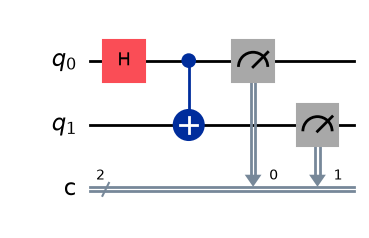

In [2]:
# 1. QuantumCircuit: build a program and draw it
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)   # 2 qubits, 2 classical bits to hold measurement results
qc.h(0)                     # Hadamard on qubit 0
qc.cx(0, 1)                 # CNOT: control qubit 0, target qubit 1
qc.measure([0, 1], [0, 1])  # measure qubit i into classical bit i

display(qc.draw('mpl'))     # 'mpl' = matplotlib drawing. Try qc.draw('text') too.

In [3]:
# 2. Statevector: the exact state (needs a circuit WITHOUT measurements)
from qiskit.quantum_info import Statevector

qc_no_measure = qc.remove_final_measurements(inplace=False)
state = Statevector(qc_no_measure)

display(state.draw('latex'))            # pretty ket notation
print(state.probabilities_dict())      # exact probabilities of each outcome

<IPython.core.display.Latex object>

{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


In [4]:
# 3. Operator: the matrix of the whole circuit
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex

U = Operator(qc_no_measure)
array_to_latex(U.data, prefix="U_{\\text{circuit}} = ")

<IPython.core.display.Latex object>

{'11': 497, '00': 503}


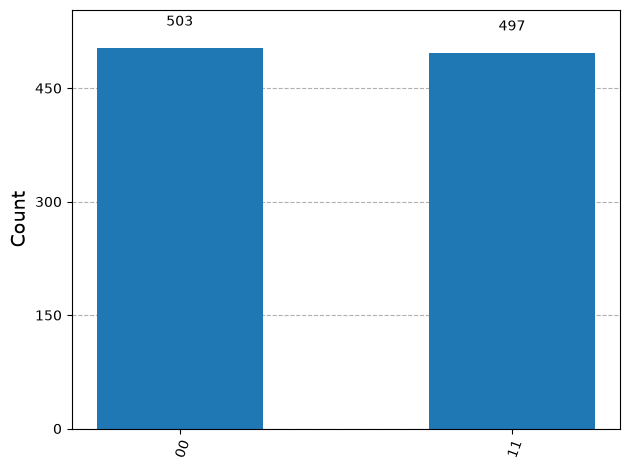

In [5]:
# 4. AerSimulator: run the circuit many times ("shots") like a real device would
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

## Interactive labs

Sliders show you one number at a time. The labs let you *build* something, predict, and then look. They live in the `qclab`
folder next to these notebooks and import with one line. (The import works because Jupyter starts each notebook's kernel in the notebook's own folder.)

| Lab | Where | What you do |
|-----|-------|-------------|
| Bloch Sphere Lab | Modules 1 and 2 | Press gates, watch the arrow and its path, read the amplitudes and the running matrix. Optional target state to reach. |
| Circuit Composer | Modules 2 and 3 | Build circuits on 1 to 4 qubits. Live drawing, amplitudes with phase colour, sampled histogram, per-qubit purity and Bloch arrows. |
| Guess the State | Modules 1 and 4 | A hidden qubit and a shot budget. Measure in Z, X or Y, then guess. Scored by fidelity. |
| Bell Test Lab | Module 3 | Pick a two-qubit state and four measurement angles. Watch the correlations and the CHSH value cross the classical limit. |
| Teleportation Walkthrough | Module 5 | Step through the protocol stage by stage with a random outcome for Alice's bits. |
| Grover Stepper | Module 7 | Step or play through iterations. Amplitude bars on the left, the rotating arrow on the right. |
| Noise Dial | Module 8 | Dial in error rates and see what they do to a Bell pair, GHZ, Grover, or your own composer circuit. |
| Checkpoint quiz | every module | Four questions with instant feedback. |

Try the composer now with the Bell pair loaded. Change the example, add gates, watch the purity readout.

Circuit Composer (static preview). Run this cell in JupyterLab for the interactive version.


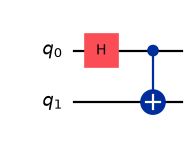

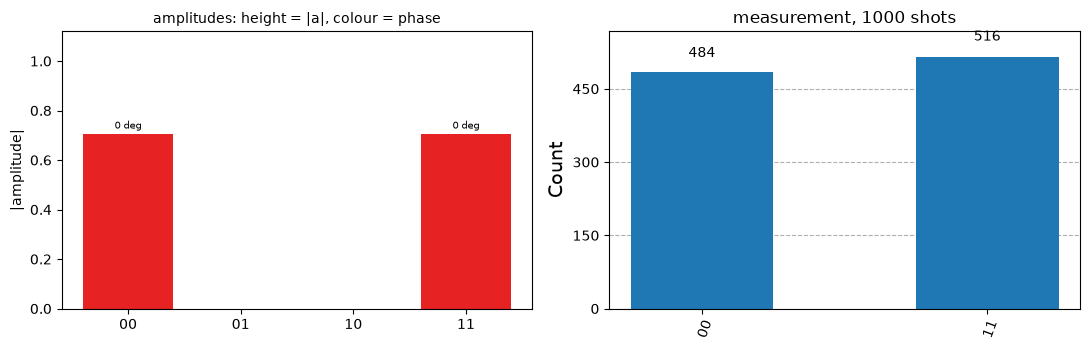

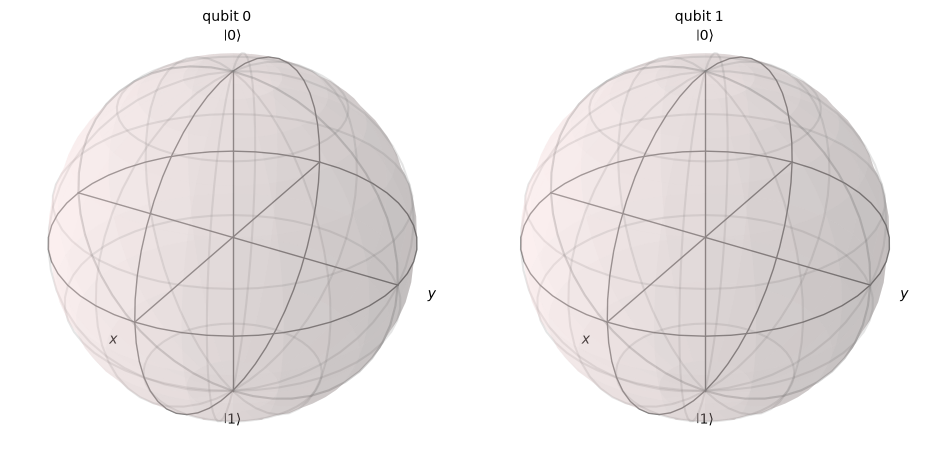

In [6]:
from qclab import bloch_lab, circuit_composer, guess_the_state, quiz

circuit_composer(2, example='bell')

## Conventions you must know

**Qubit order is little-endian.** Qiskit writes the bitstring with **qubit 0 on the right**.
A result of `'10'` means qubit 1 = 1 and qubit 0 = 0. In circuit drawings, qubit 0 is the *top* wire.
This bites everyone once. Module 3 shows it explicitly.

**Shots.** A simulator run with `shots=1000` prepares the state and measures it 1000 times.
The histogram shows *counts*, not probabilities. Divide by shots to estimate probabilities. Module 4 shows how the estimate improves with more shots.

**`Statevector` vs simulator.** `Statevector` is exact and instant but only for circuits without measurement (and it does not scale past a few dozen qubits).
`AerSimulator` mimics a real device: random outcomes, statistics, optionally noise.

**Angles are in radians.** `qc.ry(3.14159, 0)` is a half turn.

## Notation cheat sheet

| Symbol | Meaning |
|--------|---------|
| $\lvert 0\rangle, \lvert 1\rangle$ | The two basis states of a qubit, column vectors $(1,0)^T$ and $(0,1)^T$ |
| $\lvert\psi\rangle = \alpha\lvert 0\rangle + \beta\lvert 1\rangle$ | A general qubit state; $\alpha,\beta$ are complex **amplitudes** |
| $\lvert\alpha\rvert^2 + \lvert\beta\rvert^2 = 1$ | Normalisation: probabilities add to 1 |
| $\lvert +\rangle, \lvert -\rangle$ | $\tfrac{1}{\sqrt2}(\lvert 0\rangle \pm \lvert 1\rangle)$, the X-axis states |
| $\lvert 01\rangle$ | Two qubits; in Qiskit this is $\lvert q_1 q_0\rangle$ |
| $\otimes$ | Tensor product, combining systems |
| $U$ | A unitary matrix (a gate): $U^\dagger U = I$ |

## Gate cheat sheet

| Gate | Qiskit | Matrix | On the Bloch sphere |
|------|--------|--------|---------------------|
| X | `qc.x(q)` | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | 180° about X (bit flip) |
| Y | `qc.y(q)` | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | 180° about Y |
| Z | `qc.z(q)` | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | 180° about Z (phase flip) |
| H | `qc.h(q)` | $\tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | swaps X and Z axes; makes superposition |
| S | `qc.s(q)` | $\begin{pmatrix}1&0\\0&i\end{pmatrix}$ | 90° about Z |
| T | `qc.t(q)` | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ | 45° about Z |
| RX, RY, RZ | `qc.rx(θ,q)` ... | rotation by $\theta$ | any angle about X, Y, Z |
| CNOT | `qc.cx(c,t)` | $4\times4$, see Module 3 | flips target if control is 1 |
| CZ | `qc.cz(a,b)` | diag$(1,1,1,-1)$ | phase flip if both are 1 |
| Toffoli | `qc.ccx(a,b,t)` | $8\times8$ | flips target if both controls are 1 |

## Glossary

* **Amplitude**: the complex number in front of a basis state. Its squared magnitude is a probability; its sign/phase causes interference.
* **Bloch sphere**: a globe on which every single-qubit pure state is a point. Poles are $\lvert 0\rangle$ and $\lvert 1\rangle$.
* **Collapse**: after measurement the state becomes the outcome you observed; the superposition is gone.
* **Entanglement**: a multi-qubit state that cannot be written as a product of single-qubit states. Measuring one qubit tells you about the other.
* **Interference**: amplitudes for the same outcome adding (constructive) or cancelling (destructive). The engine of every quantum algorithm.
* **Oracle**: a black-box circuit that encodes a function; algorithms query it.
* **Shot**: one full run of a circuit ending in measurement.
* **Superposition**: a state with more than one non-zero amplitude.
* **Transpile**: rewrite a circuit using only the gates and qubit connections a specific device supports.
* **Unitary**: a matrix with $U^\dagger U = I$. All gates are unitary, so all gates are reversible.

[Course Index](00_Start_Here.ipynb)  |  [Next: Module 1: The Qubit & Superposition](01_The_Qubit_and_Superposition.ipynb)